In [1]:
import glob
import re
import sys
import ast
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib
import pingouin
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import ListedColormap
from matplotlib.lines import Line2D
from matplotlib.text import Text
from utils import *

In [2]:
sampling_df = pd.read_csv("Sampling_experiment_day_matches.txt", sep="\t")
rep_time_df = pd.read_csv("rep_time.tsv", sep="\t", index_col=0)

In [3]:
species_dict = {"Bd": 'Brevundimonas_diminuta_HAMBI_18',
                "Ct": 'Comamonas_testosteroni_HAMBI_403',
                "Ec": 'Escherichia_coli_ATCC_11303',
                "Jl": 'Janthinobacterium_lividum_HAMBI_1919',
                "Sm": 'Serratia_marcescens_ATCC_13880',
                "Sc": 'Sphingomonas_capsulata_HAMBI_103',
                "Pf": 'Pseudomonas_fluorescens_SBW25'}

exp_dict = {"PS": "bacteria-ciliate",
            "NP": "bacteria_alone"}

replicates = ["PS_Bd_r01", "PS_Bd_r02", "PS_Bd_r03",
              "PS_Ct_r01", "PS_Ct_r02", "PS_Ct_r03",
              "PS_Pf_r01", "PS_Pf_r02", "PS_Pf_r03",
              "PS_Sc_r01", "PS_Sc_r02", "PS_Sc_r03",
              "PS_Sm_r01", "PS_Sm_r02", "PS_Sm_r03",
              "NP_Bd_r01", "NP_Bd_r02", "NP_Bd_r03",
              "NP_Ct_r01", "NP_Ct_r02", "NP_Ct_r03",
              "NP_Pf_r01", "NP_Pf_r02", "NP_Pf_r03",
              "NP_Sc_r01", "NP_Sc_r02", "NP_Sc_r03",
              "NP_Sm_r01", "NP_Sm_r02", "NP_Sm_r03"]


In [4]:
mut_df = pd.read_csv("variants.csv")
gene_occurence_df = pd.read_csv("recurrent_genes.csv", index_col=0)

## Recurrence statistics

In [5]:
from pingouin import ancova

stats_df = pd.DataFrame(index=gene_occurence_df.columns, columns=["Experiment", "Bd", "Ct", "Pf", "Sc", "Sm"])
for gene in gene_occurence_df.columns:
    gene_hits = gene_occurence_df[gene]
    species = [x.split("_")[1] for x in gene_occurence_df.index]
    hit_df = pd.DataFrame({"Species": species, "Hit": gene_hits.astype(int)})
    hit_df = pd.get_dummies(hit_df)
    hit_df["Experiment"] = [x.split("_")[0] for x in gene_occurence_df.index]
    
    res = ancova(data=hit_df, dv="Hit", between="Experiment", covar=["Species_Bd", "Species_Ct", "Species_Pf", "Species_Sc", "Species_Sm"])
    stats_df.loc[gene, "Experiment"] = res["p-unc"].values[0]
    stats_df.loc[gene, "Bd"] = res["p-unc"].values[1]
    stats_df.loc[gene, "Ct"] = res["p-unc"].values[2]
    stats_df.loc[gene, "Pf"] = res["p-unc"].values[3]
    stats_df.loc[gene, "Sc"] = res["p-unc"].values[4]
    stats_df.loc[gene, "Sm"] = res["p-unc"].values[5]
stats_df

,Experiment,Bd,Ct,Pf,Sc,Sm
ppk,0.146656,0.001297,0.024507,0.016972,0.024507,0.016972
sasA,0.018005,0.835325,0.40887,0.40887,0.070708,0.029696
rpoB,0.011444,0.082328,0.082328,0.373633,0.654406,0.373633
hldE,0.115523,0.00178,0.593772,0.593772,0.593772,0.593772
ndhB,0.239555,0.001462,0.554865,0.377941,0.377941,0.377941
pnp,0.239555,0.001462,0.554865,0.377941,0.377941,0.377941
mrcA,0.115523,0.000001,0.150135,0.150135,0.150135,0.150135
bfrD,0.115523,0.003456,0.4254,0.4254,0.4254,0.4254
glpK,1.0,0.000002,0.342116,0.064425,0.023305,0.023305
btuB,0.54605,0.000076,0.200049,0.841062,0.200049,0.200049


In [6]:
stats_df[(stats_df["Experiment"] <= 0.05)].sort_index()

,Experiment,Bd,Ct,Pf,Sc,Sm
barA,0.021983,0.4254,0.4254,0.4254,0.4254,0.000021
cheB,0.021983,0.235688,0.235688,0.000059,0.235688,0.235688
dppB,0.021983,0.235688,0.235688,0.000059,0.235688,0.235688
flhC,0.021983,0.235688,0.235688,0.235688,0.235688,0.000059
lptA,0.031923,0.269164,0.779762,0.102679,0.269164,0.779762
puuR,0.021983,0.4254,0.4254,0.000021,0.4254,0.4254
rcsC,0.028205,0.446983,0.012335,0.135119,0.065135,0.446983
relA,0.021983,0.4254,0.000021,0.4254,0.4254,0.4254
rpoB,0.011444,0.082328,0.082328,0.373633,0.654406,0.373633
rpoC,0.016356,0.212047,1.0,1.0,1.0,0.212047


In [7]:
stats_df[(stats_df["Experiment"] <= 0.05) | (stats_df["Bd"] <= 0.05) | (stats_df["Ct"] <= 0.05) | (stats_df["Pf"] <= 0.05) | (stats_df["Sc"] <= 0.05) | (stats_df["Sm"] <= 0.05)]

,Experiment,Bd,Ct,Pf,Sc,Sm
ppk,0.146656,0.001297,0.024507,0.016972,0.024507,0.016972
sasA,0.018005,0.835325,0.40887,0.40887,0.070708,0.029696
rpoB,0.011444,0.082328,0.082328,0.373633,0.654406,0.373633
hldE,0.115523,0.00178,0.593772,0.593772,0.593772,0.593772
ndhB,0.239555,0.001462,0.554865,0.377941,0.377941,0.377941
pnp,0.239555,0.001462,0.554865,0.377941,0.377941,0.377941
mrcA,0.115523,0.000001,0.150135,0.150135,0.150135,0.150135
bfrD,0.115523,0.003456,0.4254,0.4254,0.4254,0.4254
glpK,1.0,0.000002,0.342116,0.064425,0.023305,0.023305
btuB,0.54605,0.000076,0.200049,0.841062,0.200049,0.200049


## Mutation counts over time

In [8]:
variant_data_dir = "vcfs/"
min_2_consecutive_threshold = 0.1
emergence_threshold = 0.2
disappearance_threshold = 0.1
day_cutoff = 800
mut_cumsum_dict = {}

for replicate in replicates:
    f = variant_data_dir + replicate + "_filtered_anno.vcf"
    header = None
    with open(f, "r") as file:
        for line in file:
            if re.search("^#CHROM", line):
                header = line.split("\t")
    header[0] = header[0][1:]
    header[-1] = header[-1][:-1]

    df = pd.read_csv(f, sep="\t", comment="#", header=None)
    df.columns = header
    samples = df.columns.values[9:]

    chosen_days = ast.literal_eval(rep_time_df.loc[replicate, "Days"])
    chosen_samples = ast.literal_eval(rep_time_df.loc[replicate, "Samples"])
    chosen_dates = ast.literal_eval(rep_time_df.loc[replicate, "Dates"])

    flag_for_deletion = np.array([False if len(str(x)) != 1 else True for x in df["ALT"]])
    df = df[flag_for_deletion]
    df = df.loc[:, list(df.columns.values[:9]) + chosen_samples]

    afs = df.iloc[:, 9:].to_numpy().astype(str)
    mean_after_emergence = []
    min_2_consecutive = []
    emerged_time = []
    
    for i in range(afs.shape[0]):
        min_2_consecutive_flag = False
        prev_val = -1
        where_emerged = []
        for j in range(afs.shape[1]):
            afs[i, j] = afs[i, j].split(":")[2]
            if prev_val > min_2_consecutive_threshold and float(afs[i, j]) > min_2_consecutive_threshold:
                min_2_consecutive_flag = True
                where_emerged.append(j-1)
            prev_val = float(afs[i, j])
                
        min_2_consecutive.append(min_2_consecutive_flag)    

        if len(where_emerged) > 0:
            first_emergence_idx = where_emerged[0]
            mean_after_emergence.append(np.sum(afs[i].astype(float)[first_emergence_idx:])/len(afs[i].astype(float)[first_emergence_idx:]))
            emerged_time.append(int(ast.literal_eval(rep_time_df.loc[replicate, "Days"])[first_emergence_idx]))
        else:
            mean_after_emergence.append(np.nan)
            emerged_time.append(np.nan)

    disappearance_time = np.ones(afs.shape[0])*chosen_days[-1]
    for i in range(afs.shape[0]):
        for j in range(afs.shape[1]):
            if np.all(afs[i, j:].astype(float) < disappearance_threshold):
                disappearance_time[i] = ast.literal_eval(rep_time_df.loc[replicate, "Days"])[j]
                break
    
    df = df.loc[min_2_consecutive]
    afs = afs[min_2_consecutive]
    mean_after_emergence = np.array(mean_after_emergence)[min_2_consecutive]
    emerged_time = np.array(emerged_time)[min_2_consecutive]
    disappearance_time = np.array(disappearance_time)[min_2_consecutive]
    
    samples = df.columns.values[9:]
    seen_mutations = []
    new_muts_per_sample = []
    for sample in samples:
        sample_afs = np.array([x.split(":")[2] for x in df[sample]]).astype(float)
        new_muts = list(np.where(sample_afs >= 0.1)[0])
        new_muts_per_sample.append(len([x for x in new_muts if x not in seen_mutations]))
        seen_mutations = list(set(seen_mutations + new_muts))

    mut_cumsum_dict[replicate] = [sum(new_muts_per_sample[:i]) for i in range(len(new_muts_per_sample))]

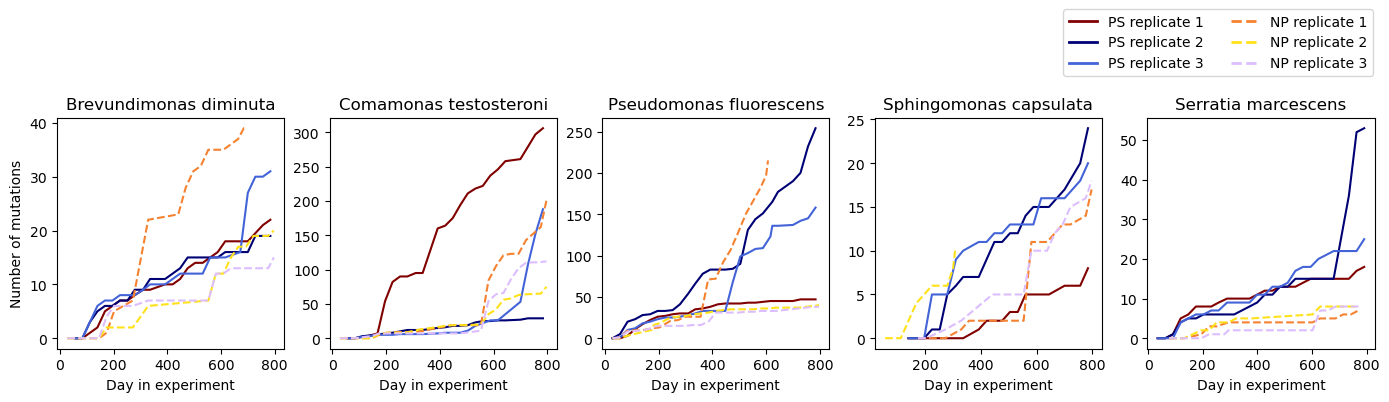

In [9]:
species_colors_dict = {"Bd": "tab:blue",
                       "Ct": "tab:orange",
                       "Pf": "tab:green",
                       "Sc": "tab:purple",
                       "Sm": "tab:olive"}

replicate_colors_dict = {1: "tab:blue",
                         2: "tab:orange",
                         3: "tab:green"}

replicate_colors_dict_2 = {"PS_r01": "#800000",
                           "PS_r02": "#000075",
                           "PS_r03": "#4363d8",
                           "NP_r01": "#f58231",
                           "NP_r02": "#ffe119",
                           "NP_r03": "#dcbeff"}

species_names_dict = {"Bd": "Brevundimonas diminuta",
                      "Ct": "Comamonas testosteroni",
                      "Pf": "Pseudomonas fluorescens",
                      "Sc": "Sphingomonas capsulata",
                      "Sm": "Serratia marcescens"}

total_muts = 0
plt.subplots(1, 5, figsize=(17, 3))
si = 1
for species in ["Bd", "Ct", "Pf", "Sc", "Sm"]:
    plt.subplot(1, 5, si)
    for replicate in [x for x in replicates if species in x]:
        experiment = replicate.split("_")[0]
        if experiment == "PS":
            linestyle = "solid"
        else:
            linestyle = "dashed"

        x = ast.literal_eval(rep_time_df.loc[replicate, "Days"])
        y = np.array(mut_cumsum_dict[replicate])
        total_muts += mut_cumsum_dict[replicate][-1]
        plt.plot(x, y, color=replicate_colors_dict_2[replicate.split("_")[0] + "_" + replicate.split("_")[2]], linestyle=linestyle)
    si += 1
    # plt.ylim(-0.1, 3.1)
    plt.title(species_names_dict[species])
    plt.xlabel("Day in experiment")

plt.subplot(1, 5, 1)
plt.ylabel("Number of mutations")

plt.subplot(1, 5, 5)
custom_legend = [Line2D([0], [0], color="#800000", lw=2, linestyle="solid", label="PS replicate 1"),
                 Line2D([0], [0], color="#000075", lw=2, linestyle="solid", label="PS replicate 2"),
                 Line2D([0], [0], color="#4363d8", lw=2, linestyle="solid", label="PS replicate 3"),
                 Line2D([0], [0], color="#f58231", lw=2, linestyle="dashed", label="NP replicate 1"),
                 Line2D([0], [0], color="#ffe119", lw=2, linestyle="dashed", label="NP replicate 2"),
                 Line2D([0], [0], color="#dcbeff", lw=2, linestyle="dashed", label="NP replicate 3")]

plt.legend(handles=custom_legend, bbox_to_anchor=(1.025, 1.5), ncols=2)
plt.show()

In [10]:
from scipy.stats import ttest_ind

acc_muts = np.array([mut_cumsum_dict[replicate][-1] for replicate in replicates])
PS_muts = acc_muts[:15]
NP_muts = acc_muts[15:]

print(ttest_ind(NP_muts[:3], PS_muts[:3], equal_var=False)[1])
print(ttest_ind(NP_muts[3:6], PS_muts[3:6], equal_var=False)[1])
print(ttest_ind(NP_muts[6:9], PS_muts[6:9], equal_var=False)[1])
print(ttest_ind(NP_muts[9:12], PS_muts[9:12], equal_var=False)[1])
print(ttest_ind(NP_muts[12:], PS_muts[12:], equal_var=False)[1])

0.9401011028345239
0.6482324457603004
0.545068328028016
0.6960333946484781
0.15051549563229083


# Gene recurrence heatmap

In [11]:
order = ["PS_Bd_r01", "PS_Bd_r02", "PS_Bd_r03",
         "NP_Bd_r01", "NP_Bd_r02", "NP_Bd_r03",
         "PS_Ct_r01", "PS_Ct_r02", "PS_Ct_r03",
         "NP_Ct_r01", "NP_Ct_r02", "NP_Ct_r03",
         "PS_Pf_r01", "PS_Pf_r02", "PS_Pf_r03",
         "NP_Pf_r01", "NP_Pf_r02", "NP_Pf_r03",
         "PS_Sc_r01", "PS_Sc_r02", "PS_Sc_r03",
         "NP_Sc_r01", "NP_Sc_r02", "NP_Sc_r03",
         "PS_Sm_r01", "PS_Sm_r02", "PS_Sm_r03",
         "NP_Sm_r01", "NP_Sm_r02", "NP_Sm_r03"]

In [12]:
species = ["Bd", "Ct", "Pf", "Sc", "Sm"]
gene_occurence_exp_rowsum_df = pd.DataFrame(index=["PS_Bd", "PS_Ct", "PS_Pf", "PS_Sc", "PS_Sm", "NP_Bd", "NP_Ct", "NP_Pf", "NP_Sc", "NP_Sm"], columns=gene_occurence_df.columns)
for i in range(0, 30, 3):
    rowsum = gene_occurence_df.iloc[i:i+3].sum(axis=0)
    gene_occurence_exp_rowsum_df.loc["_".join(gene_occurence_df.index[i:i+3][0].split("_")[:2])] = pd.Series([1 if x >= 2 else 0 for x in rowsum], index=rowsum.index)
    
for idx in gene_occurence_exp_rowsum_df.index[:5]:
    x = gene_occurence_exp_rowsum_df.loc[idx]
    x[x == 1] = 2
    gene_occurence_exp_rowsum_df.loc[idx] = x
gene_occurence_exp_rowsum_df = gene_occurence_exp_rowsum_df.iloc[:, np.where(gene_occurence_exp_rowsum_df.sum(axis=0) != 0)[0]]

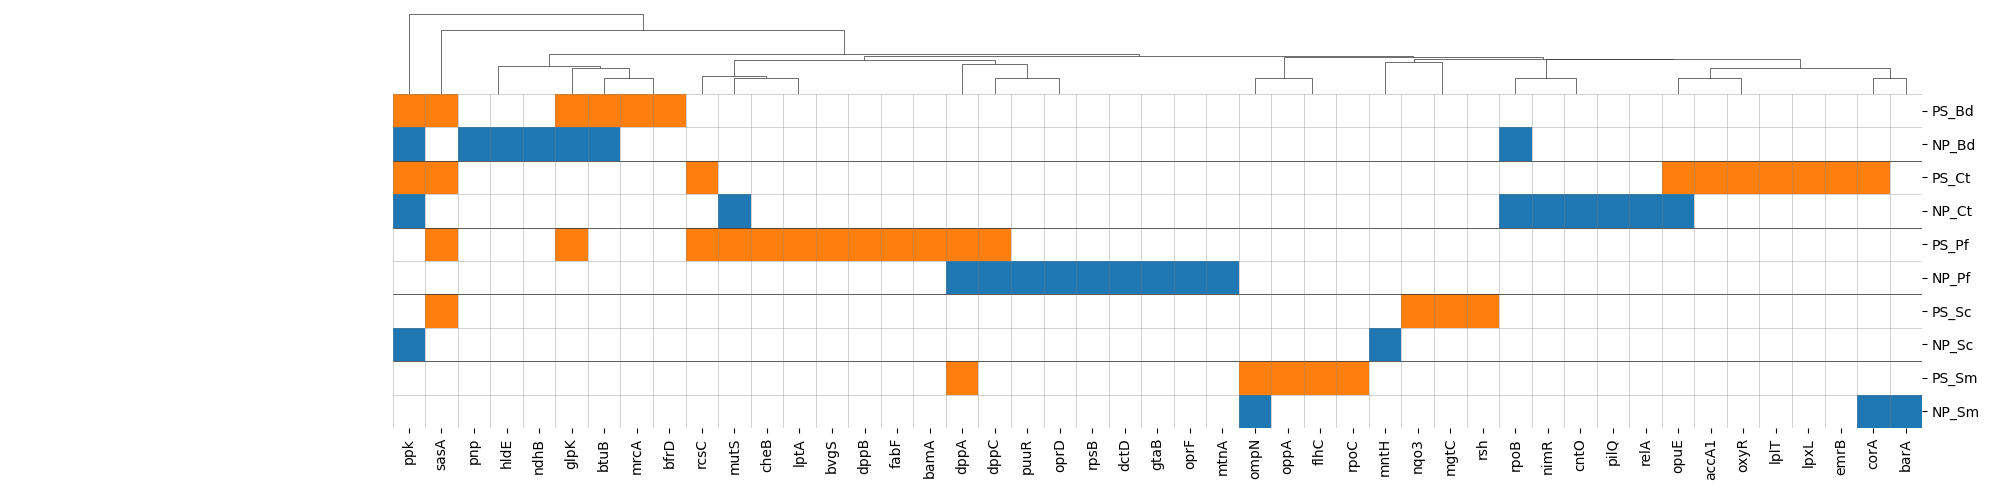

In [13]:
df = gene_occurence_exp_rowsum_df
ncols = len(df.columns)
nrows = len(df.index)
custom_cmap = ListedColormap(['white', 'tab:blue', 'tab:orange'])

clustermap = sns.clustermap(df.loc[["PS_Bd", "NP_Bd", "PS_Ct", "NP_Ct", "PS_Pf", "NP_Pf", "PS_Sc", "NP_Sc", "PS_Sm", "NP_Sm"]].astype(int), 
                            col_cluster=True, row_cluster=False, figsize=(20, 5), cmap=custom_cmap, cbar_pos=None, dendrogram_ratio=0.2, method="average", metric="hamming")
ax = clustermap.ax_heatmap
ax.hlines(2, 0, ncols, color="k", lw=0.5)
ax.hlines(4, 0, ncols, color="k", lw=0.5)
ax.hlines(6, 0, ncols, color="k", lw=0.5)
ax.hlines(8, 0, ncols, color="k", lw=0.5)

for i in range(-1, ncols+1):
    ax.vlines(i-1, 0, nrows, color="gray", lw=0.5, alpha=0.5)

for i in range(-1, nrows+1):
    ax.hlines(i-1, 0, ncols, color="gray", lw=0.5, alpha=0.5)

ordered_genes = [x.get_text() for x in ax.get_xticklabels()]

In [50]:
cluster_clone_match_all = pd.read_csv("cluster_clone_match.tsv", sep="\t")
genes = list(gene_occurence_exp_rowsum_df.columns)
mut_clone_df = pd.DataFrame(columns=["ID", "Replicate", "Gene", "Cluster", "Clone", "Day"])
for gene in genes:
    rec_mut_reps = list(gene_occurence_exp_rowsum_df[gene][gene_occurence_exp_rowsum_df[gene] != 0].index)
    for rec_rep in rec_mut_reps:
        replicates = [rec_rep + "_r01", rec_rep + "_r02", rec_rep + "_r03"]
        for replicate in replicates:
            rep_days = ast.literal_eval(rep_time_df.loc[replicate, "Days"])
            cluster_clone_match = cluster_clone_match_all[cluster_clone_match_all["Replicate"] == replicate]
            pyclone_output = pd.read_csv("pyclone_output/" + replicate + "_final.tsv", sep="\t")

            # Removing artefactual cohorts (like in clonal inference)
            muts_to_remove = []
            if replicate == "PS_Pf_r01":
                muts_to_remove = list(pyclone_output[pyclone_output["cluster_id"] == 5]["mutation_id"])
                pyclone_output = pyclone_output[pyclone_output["cluster_id"] != 5]
                
            if replicate == "PS_Pf_r02":
                muts_to_remove = list(pyclone_output[pyclone_output["cluster_id"] == 2]["mutation_id"])
                pyclone_output = pyclone_output[pyclone_output["cluster_id"] != 2]
                dict_replace = {3: 2, 4: 3, 5: 4, 6: 5, 7: 6}
                pyclone_output = pyclone_output.replace({"cluster_id": dict_replace})
        
            if replicate == "NP_Bd_r03":
                muts_to_remove = list(pyclone_output[pyclone_output["cluster_id"] == 4]["mutation_id"])
                pyclone_output = pyclone_output[pyclone_output["cluster_id"] != 4]
                dict_replace = {4: 3, 5: 4, 6: 5}
                pyclone_output = pyclone_output.replace({"cluster_id": dict_replace})
        
            if replicate == "NP_Pf_r03":
                muts_to_remove = list(pyclone_output[pyclone_output["cluster_id"] == 2]["mutation_id"])
                pyclone_output = pyclone_output[pyclone_output["cluster_id"] != 2]
                dict_replace = {3: 2, 4: 3, 5: 4, 6: 5}
                pyclone_output = pyclone_output.replace({"cluster_id": dict_replace})


            temp_df = mut_df[(mut_df["EXPERIMENT"] == replicate.split("_")[0]) & (mut_df["SPECIES"] == replicate.split("_")[1]) & (mut_df["REPLICATE"] == int(replicate.split("_")[2][-1])) & (mut_df["GENE ALT"] == gene)]
            mut_ids = [temp_df.loc[i, "CHROM"] + "_" + str(temp_df.loc[i, "POS"]) for i in temp_df.index]
            mut_ids = [x for x in mut_ids if not x in muts_to_remove]

            for mut_id in mut_ids:
                cluster = pyclone_output[pyclone_output["mutation_id"] == mut_id]["cluster_id"].values[0]
                assert np.all(pyclone_output[pyclone_output["mutation_id"] == mut_id]["cluster_id"] == cluster)
                mut_clone_df.loc[mut_id, "ID"] = mut_id
                mut_clone_df.loc[mut_id, "Replicate"] = replicate
                mut_clone_df.loc[mut_id, "Gene"] = gene
                mut_clone_df.loc[mut_id, "Cluster"] = cluster
                mut_clone_df.loc[mut_id, "Clone"] = cluster_clone_match[cluster_clone_match["Cluster"] == cluster]["Clone"].values[0]
                mut_clone_df.loc[mut_id, "Day"] = rep_days[cluster_clone_match[cluster_clone_match["Cluster"] == cluster]["Time of emergence"].values[0]]
mut_clone_df            

,ID,Replicate,Gene,Cluster,Clone,Day
HAMBI_0018_chrm01_circ_1083792,HAMBI_0018_chrm01_circ_1083792,PS_Bd_r01,ppk,2,ADG,616
HAMBI_0018_chrm01_circ_1082322,HAMBI_0018_chrm01_circ_1082322,PS_Bd_r03,ppk,6,CDG,672
HAMBI_0403_chrm01_circ_3909911,HAMBI_0403_chrm01_circ_3909911,PS_Ct_r01,ppk,5,B,168
HAMBI_0403_chrm01_circ_3910271,HAMBI_0403_chrm01_circ_3910271,PS_Ct_r01,ppk,2,CD,336
HAMBI_0403_chrm01_circ_3910589,HAMBI_0403_chrm01_circ_3910589,PS_Ct_r03,ppk,2,AC,448
...,...,...,...,...,...,...
HAMBI_0103_chrm01_circ_1883756,HAMBI_0103_chrm01_circ_1883756,PS_Sc_r02,rsh,0,BCEF,700
HAMBI_0103_chrm01_circ_1884790,HAMBI_0103_chrm01_circ_1884790,PS_Sc_r02,rsh,0,BCEF,700
HAMBI_0103_chrm01_circ_1884242,HAMBI_0103_chrm01_circ_1884242,PS_Sc_r03,rsh,0,ADFG,756
HAMBI_0103_chrm01_circ_3145147,HAMBI_0103_chrm01_circ_3145147,PS_Sc_r02,nqo3,0,BCEF,700


In [51]:
alt_mut_day_df = pd.DataFrame(columns=["Gene", "Replicate", "Experiment", "Day"])

for gene in ordered_genes:
    gene_mut_clone_df = mut_clone_df[mut_clone_df["Gene"] == gene].copy()
    gene_mut_clone_df["Experiment"] = [x.split("_")[0] for x in gene_mut_clone_df["Replicate"]]
    
    for exp in gene_mut_clone_df["Experiment"].unique():
        exp_gene_mut_clone_df = gene_mut_clone_df[gene_mut_clone_df["Experiment"] == exp]
        if not len(exp_gene_mut_clone_df["Replicate"].unique()) < 2:
            for row_id in exp_gene_mut_clone_df.index:
                alt_mut_day_df.loc[len(alt_mut_day_df)] = [gene, exp_gene_mut_clone_df.loc[row_id]["Replicate"], exp, exp_gene_mut_clone_df.loc[row_id]["Day"]]


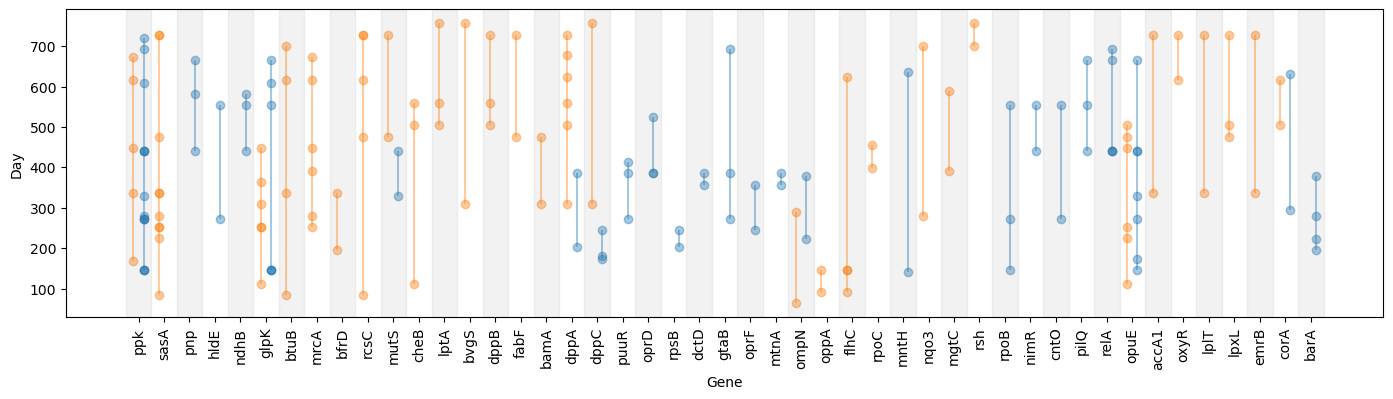

In [52]:
exp_color_dict = {"PS": "tab:orange", "NP": "tab:blue"}
exp_spacer_dict = {"PS": -0.2, "NP": 0.2}

alt_mut_day_df = alt_mut_day_df.drop_duplicates()

i = 0
plt.figure(figsize=(17, 4))

for gene in alt_mut_day_df["Gene"].unique():
    gene_df = alt_mut_day_df[alt_mut_day_df["Gene"] == gene]
    for exp in gene_df["Experiment"].unique():
        days = gene_df[gene_df["Experiment"] == exp]["Day"]
        for day in days:
            plt.scatter(i+exp_spacer_dict[exp], day, color=exp_color_dict[exp], alpha=0.4)
        plt.vlines(i+exp_spacer_dict[exp], days.min(), days.max(), color=exp_color_dict[exp], alpha=0.4)

    if i%2 == 0:
        plt.axvspan(i-0.5, i+0.5, color='gray', alpha=0.1)
    i += 1
    
plt.xlabel("Gene")
plt.ylabel("Day")
plt.xticks(range(0, len(alt_mut_day_df["Gene"].unique())*1, 1), alt_mut_day_df["Gene"].unique(), rotation=90)
plt.show()

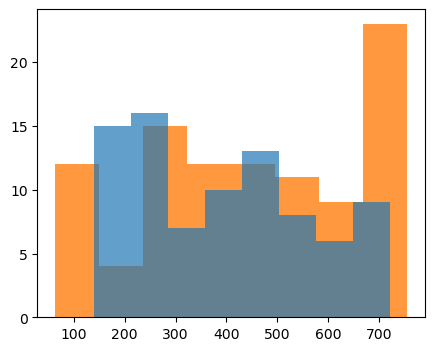

In [53]:
ps_days = list(alt_mut_day_df[alt_mut_day_df["Experiment"] == "PS"]["Day"])
np_days = list(alt_mut_day_df[alt_mut_day_df["Experiment"] == "NP"]["Day"])

plt.figure(figsize=(5, 4))
plt.hist(ps_days, bins=8, alpha=0.8, color="tab:orange")
plt.hist(np_days, bins=8, alpha=0.7, color="tab:blue")
plt.show()

In [54]:
from scipy.stats import kstest
kstest(ps_days, np_days)

KstestResult(statistic=0.28741496598639454, pvalue=0.0008604221622275384, statistic_location=441, statistic_sign=-1)